use magic jupyter widget to get dir listing

In [1]:
%ls

data.csv  pandas.ipynb


In [2]:
import pandas as pd
dataframe = pd.read_csv("data.csv")

slice = dataframe.iloc[10:20] #slice is rows 10 - 19
slice = slice.iloc[:,0:4] #slice is first 4 cdolumns only
print(slice)

    Duration          Date  Pulse  Maxpulse
10        60  '2020/12/11'    103       147
11        60  '2020/12/12'    100       120
12        60  '2020/12/12'    100       120
13        60  '2020/12/13'    106       128
14        60  '2020/12/14'    104       132
15        60  '2020/12/15'     98       123
16        60  '2020/12/16'     98       120
17        60  '2020/12/17'    100       120
18        45  '2020/12/18'     90       112
19        60  '2020/12/19'    103       123


Example of binary filter on a dataframe to exclude edge case pulse readings


In [3]:
print(slice['Pulse'].dtype)
#data = df[df['Age'] > 35]
boolslice = dataframe[(dataframe['Pulse'] > 98) & (dataframe['Maxpulse'] < 128)]

print(boolslice)

int64
    Duration          Date  Pulse  Maxpulse  Calories
5         60  '2020/12/06'    102       127     300.0
11        60  '2020/12/12'    100       120     250.7
12        60  '2020/12/12'    100       120     250.7
17        60  '2020/12/17'    100       120     300.0
19        60  '2020/12/19'    103       123     323.0
22        45           NaN    100       119     282.0
23        60  '2020/12/23'    130       101     300.0
25        60  '2020/12/25'    102       126     334.5
26        60      20201226    100       120     250.0


Determine datatype of a field, Drop a row, and convert a columns data into a type we can sort and filter

In [4]:
print(dataframe['Date'].dtype)
dataframe.drop(26, inplace=True)
dataframe['Date'] = dataframe['Date'].str.replace("'", "")
dataframe['Date'] = pd.to_datetime(dataframe['Date'], format='%Y/%m/%d')
print(dataframe)

object
    Duration       Date  Pulse  Maxpulse  Calories
0         60 2020-12-01    110       130     409.1
1         60 2020-12-02    117       145     479.0
2         60 2020-12-03    103       135     340.0
3         45 2020-12-04    109       175     282.4
4         45 2020-12-05    117       148     406.0
5         60 2020-12-06    102       127     300.0
6         60 2020-12-07    110       136     374.0
7        450 2020-12-08    104       134     253.3
8         30 2020-12-09    109       133     195.1
9         60 2020-12-10     98       124     269.0
10        60 2020-12-11    103       147     329.3
11        60 2020-12-12    100       120     250.7
12        60 2020-12-12    100       120     250.7
13        60 2020-12-13    106       128     345.3
14        60 2020-12-14    104       132     379.3
15        60 2020-12-15     98       123     275.0
16        60 2020-12-16     98       120     215.2
17        60 2020-12-17    100       120     300.0
18        45 2020-12-18 

display only certain columns

         Date  Maxpulse
11 2020-12-12       120
12 2020-12-12       120
13 2020-12-13       128
14 2020-12-14       132
15 2020-12-15       123
16 2020-12-16       120
17 2020-12-17       120
18 2020-12-18       112
19 2020-12-19       123
20 2020-12-20       125
21 2020-12-21       131
23 2020-12-23       101
24 2020-12-24       132
25 2020-12-25       126
27 2020-12-27       118
28 2020-12-28       132
29 2020-12-29       132
30 2020-12-30       129
31 2020-12-31       115


<Axes: xlabel='Date', ylabel='Maxpulse'>

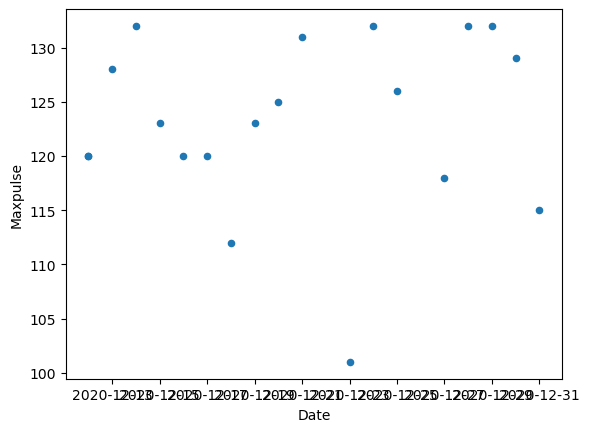

In [9]:
thisdate = dataframe.loc[(dataframe['Date'] >= '2020/12/12')]
thissubset = thisdate[['Date', 'Maxpulse']]
print(thissubset)

thissubset.plot.scatter(x='Date',y='Maxpulse')